# Stochastic AdaBoost — Multiclass Classification (Stagewise Additive Modeling using a Multi-class Exponential loss :- SAMME)

---

## 1. Problem Setup

Assume we have a dataset

$$
\{(x_i, y_i)\}_{i=1}^{N}
$$

where

$$
x_i \in \mathbb{R}^D
$$

and

$$
y_i \in \{0,1,2,\dots,K-1\}
$$

The goal is to learn a classifier that combines multiple weak learners to predict multiclass labels.

---

## 2. Model Idea

AdaBoost builds an ensemble of weak learners:

$$
\{h_m(x)\}_{m=1}^{M}
$$

Each model is assigned a weight:

$$
\alpha_m
$$

Final prediction is obtained by weighted voting across all classes.

---

## 3. Initialization

Initialize uniform sample weights:

$$
w_i^{(1)} = \frac{1}{N}, \quad i = 1,2,\dots,N
$$

---

## 4. Weighted Sampling (Stochastic AdaBoost)

At each iteration, instead of using full weighted training:

- Sample dataset using weights:

$$
\mathcal{D}^{(m)} \sim \text{Multinomial}(w^{(m)})
$$

This introduces stochasticity (sampling-based AdaBoost).

---

## 5. Weak Learner

Train a decision tree:

$$
h_m(x)
$$

using sampled data.

---

## 6. Weighted Error

Compute weighted misclassification error:

$$
\epsilon_m = \sum_{i=1}^{N} w_i^{(m)} \cdot \mathbf{1}(y_i \neq h_m(x_i))
$$

To ensure stability:

$$
\epsilon_m \in [10^{-10}, 1 - 10^{-10}]
$$

---

## 7. Model Weight (Multiclass)

For multiclass AdaBoost:

$$
\alpha_m = \log\left(\frac{1 - \epsilon_m}{\epsilon_m}\right) + \log(K - 1)
$$

where:

- $K$ = number of classes  

---

## 8. Weight Update

Define error indicator:

$$
I_i =
\begin{cases}
1 & y_i \neq h_m(x_i) \\
0 & \text{otherwise}
\end{cases}
$$

Update weights:

$$
w_i^{(m+1)} = w_i^{(m)} \cdot \exp(\alpha_m \cdot I_i)
$$

Normalize:

$$
w_i^{(m+1)} = \frac{w_i^{(m+1)}}{\sum_{j=1}^{N} w_j^{(m+1)}}
$$

---

## 9. Stopping Condition

Only accept weak learners if:

$$
0 < \epsilon_m < 1 - \frac{1}{K}
$$

Otherwise discard the model.

---

## 10. Final Prediction

For each class $k$:

$$
F_k(x) = \sum_{m=1}^{M} \alpha_m \cdot \mathbf{1}(h_m(x) = k)
$$

Final prediction:

$$
\hat{y} = \arg\max_{k} F_k(x)
$$

---

## 11. Algorithm Summary

For $m = 1$ to $M$:

$$
\text{Sample data using } w^{(m)}
$$

$$
\text{Train weak learner } h_m(x)
$$

$$
\epsilon_m = \text{weighted error}
$$

$$
\alpha_m = \log\left(\frac{1 - \epsilon_m}{\epsilon_m}\right) + \log(K - 1)
$$

$$
w_i \leftarrow w_i \cdot \exp(\alpha_m \cdot I_i)
$$

$$
\text{Normalize weights}
$$

---

## 12. Key Differences from Binary AdaBoost

### I Model Weight Formula

- **Binary AdaBoost:**

$$
\alpha_m = \frac{1}{2} \log\left(\frac{1 - \epsilon_m}{\epsilon_m}\right)
$$

- **Multiclass AdaBoost:**

$$
\alpha_m = \log\left(\frac{1 - \epsilon_m}{\epsilon_m}\right) + \log(K - 1)
$$

Additional $\log(K-1)$ term adjusts for multiple classes.



### II Error Threshold

- **Binary case:**

$$
\epsilon_m < 0.5
$$

- **Multiclass case:**

$$
\epsilon_m < 1 - \frac{1}{K}
$$

Weak learner must perform better than random guessing across $K$ classes.


### III Proof of Multiclass Error Threshold
To ensure that each weak learner $h_m$ contributes positively to the ensemble, its corresponding weight $\alpha_m$ must be greater than zero.

Given the SAMME weight formula:
$$\alpha_m = \ln \left( \frac{1 - \epsilon_m}{\epsilon_m} \right) + \ln(K - 1)$$

We require $\alpha_m > 0$:
 $$\ln \left( \frac{1 - \epsilon_m}{\epsilon_m} \cdot (K - 1) \right) > 0$$
 $$\frac{(1 - \epsilon_m)(K - 1)}{\epsilon_m} > 1$$
 $$(K - 1) - \epsilon_m K + \epsilon_m > \epsilon_m$$
 $$K - 1 > \epsilon_m K$$
 $$\epsilon_m < \frac{K - 1}{K} \implies \epsilon_m < 1 - \frac{1}{K}$$

This proves that for multiclass boosting, a weak learner only needs to be slightly better than **random guessing** ($1/K$ accuracy) to be useful.

### IV Prediction Aggregation

- **Binary:**

$$
\hat{y} = \text{sign}\left(\sum \alpha_m h_m(x)\right)
$$

- **Multiclass:**

$$
\hat{y} = \arg\max_k \sum \alpha_m \cdot \mathbf{1}(h_m(x)=k)
$$
 Uses **class-wise voting instead of sign aggregation**.



### V Output Space

- **Binary:** $y \in \{-1, +1\}$  
- **Multiclass:** $y \in \{0,1,\dots,K-1\}$  

---

## 13. Final Optimization Perspective

The model minimizes an exponential loss adapted for multiclass classification:

$$
\min \sum_{i=1}^{N} \exp(-F_{y_i}(x_i))
$$

where:

$$
F_k(x) = \sum_{m=1}^{M} \alpha_m \cdot \mathbf{1}(h_m(x)=k)
$$

---

## 14. Intuition

- Misclassified points get **higher weights**
- Model focuses on **hard-to-classify samples**
- Ensemble builds **strong classifier from weak learners**
- Multiclass extension ensures **balanced learning across all classes**

---

In [1]:
class LeafNode:
    """
    Leaf node of the decision tree.

    Attributes
    ----------
    value : int, float
        The predicted class label (for classification) or value (for regression)
        at the leaf.
    """
    def __init__(self, value):
        self.value = value
class DecisionNode:
    """
    Internal decision node of the tree.

    Attributes
    ----------
    best_feature : int
        Index of the feature used for the split.
    best_threshold : float
        Threshold value for splitting.
    left_child : LeafNode or DecisionNode
        Left subtree (samples <= threshold).
    right_child : LeafNode or DecisionNode
        Right subtree (samples > threshold).
    """
    def __init__(self, best_feature, best_threshold, left_child, right_child):
        self.best_feature = best_feature
        self.best_threshold = best_threshold
        self.left_child = left_child
        self.right_child = right_child

class DecisionTree:
    """
    Decision Tree Classifier using recursive binary splits.

    Parameters
    ----------
    max_depth : int
        Maximum depth of the tree.
    min_samples_split : int
        Minimum number of samples required to split a node.
    scoring : str
        Impurity measure: 'gini' for Gini index, 'entropy' for Information Gain.
    feature_fraction : float
        Fraction of features to consider at each split (for random feature selection).

    Attributes
    ----------
    root : DecisionNode or LeafNode
        Root node of the trained tree.
    """
    def __init__(self, max_depth=10, min_samples_split=1, scoring='gini', feature_fraction=1.0):

        
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.scoring = scoring
        self.feature_fraction = feature_fraction
        self.root = None

        # Validate
        if type(self.max_depth) != int or self.max_depth <= 0:
            raise ValueError('Max depth must be a positive integer')
        if type(self.min_samples_split) != int or self.min_samples_split <= 0:
            raise ValueError('Min samples split must be a positive integer')
        if self.scoring not in ['gini', 'entropy']:
            raise ValueError("Scoring must be either 'gini' or 'entropy'")

    def _stopping_condition(self, data, depth):
        """
        Check whether to stop splitting the current node.

        Stopping criteria:
        - Maximum depth reached
        - Not enough samples to split
        - Node is pure (all labels identical)
        """
        
        if depth >= self.max_depth:
            return True
        if len(data) < self.min_samples_split:
            return True
        if len(np.unique(data[:, -1])) == 1:
            return True
        return False

    def _score(self, left, right):
        """
        Compute the impurity score of a potential split.

        Parameters
        ----------
        left : np.array
            Labels in the left split.
        right : np.array
            Labels in the right split.

        Returns
        -------
        float
            Weighted impurity score of the split (lower is better).
        """
        n_left = len(left)
        n_right = len(right)
        

        # Avoid invalid splits
        if n_left == 0 or n_right == 0:
            return np.inf
            
        total = n_left + n_right

        counts_left = np.unique(left, return_counts=True)[1]
        counts_right = np.unique(right, return_counts=True)[1]

        probability_left = counts_left / np.sum(counts_left)
        probability_right = counts_right / np.sum(counts_right)

        if self.scoring == 'gini':
            score_left = 1 - np.sum(probability_left**2)
            score_right = 1 - np.sum(probability_right**2)
            
        # entropy    
        else:  
            score_left = -np.sum(probability_left * np.log(probability_left))
            
            score_right = -np.sum(probability_right * np.log(probability_right))
        # Weighted average of left and right impurity
        return (n_left * score_left + n_right * score_right) / total


 

    def _random_feature(self, data):
        """
        Randomly select a subset of features based on feature_fraction.

        Returns
        -------
        selected_features : np.array
            Indices of selected features for splitting.
        """
        
        n_features = data.shape[1] - 1  # exclude target
        
        n_selected = max(1, int(round(n_features * self.feature_fraction)))
        
        selected_features = np.random.choice(n_features, n_selected, replace=False)
        
        return selected_features


    def _find_all_threshold(self, data, selected_features):
        """
        Compute all candidate thresholds for each selected feature.

        Returns
        -------
        list of np.array
            Candidate threshold values for each feature.
        """
        
        all_thresholds = []
        for feature in selected_features:
            unique_vals = np.unique(data[:, feature])
            if len(unique_vals) <= 1:
                all_thresholds.append(np.array([]))
            else:
                # Midpoints between successive values
                successive_average = (unique_vals[1:] + unique_vals[:-1]) / 2
                all_thresholds.append(successive_average)
                
        return all_thresholds

    def _split(self, data, feature, threshold):
        """
        Split data into left and right subsets based on threshold.

        Parameters
        ----------
        data : np.array
        feature : int
        threshold : float

        Returns
        -------
        left : np.array
        right : np.array
        """
        condition = data[:, feature] <= threshold
        
        return data[condition], data[~condition]

    def _best_feature_threshold(self, data, selected_features, all_thresholds):
        """
        Find the best feature and threshold combination minimizing impurity.

        Returns
        -------
        best_feature : int
        best_threshold : float
        """
        
        best_score = np.inf
        best_feature = None
        best_threshold = None

        for i, feature in enumerate(selected_features):
            thresholds = all_thresholds[i]
            if len(thresholds) == 0:
                continue
            for threshold in thresholds:
                left, right = self._split(data, feature, threshold)
                score = self._score(left[:, -1], right[:, -1])
                if score < best_score:
                    best_score = score
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _find_best_split(self, data):
        """
        Function to select features, compute thresholds and find best split.
        """
        selected_features = self._random_feature(data)
        
        all_thresholds = self._find_all_threshold(data, selected_features)
        
        best_feature, best_threshold = self._best_feature_threshold(data, selected_features, all_thresholds)
        
        return best_feature, best_threshold

    def _build_tree(self, data, depth):
        """
        Recursively build the decision tree.

        Returns
        -------
        LeafNode or DecisionNode
        """
        
        if self._stopping_condition(data, depth):
            # Leaf prediction: majority class
            prediction = stats.mode(data[:, -1])[0]
            return LeafNode(prediction)

        best_feature, best_threshold = self._find_best_split(data)
        left_data, right_data = self._split(data, best_feature, best_threshold)

        # If no valid split found, create leaf
        if best_feature is None:
            prediction = stats.mode(data[:, -1])[0]
            return LeafNode(value=prediction)

        left_child = self._build_tree(left_data, depth + 1)
        right_child = self._build_tree(right_data, depth + 1)

        return DecisionNode(best_feature, best_threshold, left_child, right_child)

    def fit(self, X, y):
        """
        Fit the decision tree to the training data.

        Parameters
        ----------
        X : np.array
            Feature matrix (N x D)
        y : np.array
            Labels vector (N,)
        """
        
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        data = np.column_stack((X, y))
        self.root = self._build_tree(data, 0)

    def _predict_single(self, x, node):
        """
        Predict label for a single sample recursively.

        Parameters
        ----------
        x : np.array
            Feature vector
        node : DecisionNode or LeafNode

        Returns
        -------
        predicted label
        """
        if isinstance(node, LeafNode):
            return node.value
        if x[node.best_feature] <= node.best_threshold:
            return self._predict_single(x, node.left_child)
        else:
            return self._predict_single(x, node.right_child)

    def predict(self, X):
        """
        Predict labels for multiple samples.

        Parameters
        ----------
        X : np.array
            Feature matrix

        Returns
        -------
        np.array
            Predicted labels
        """
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        return np.array([self._predict_single(x, self.root) for x in X])

In [2]:
class AdaBoostMulticlassClassifier:
    """
    Stochastic AdaBoost Multiclass Classifier using the SAMME algorithm.

    This implementation focuses on re-weighting samples and aggregating 
    weak learners (Decision Trees) to perform multiclass classification.

    Attributes:
        n_estimators (int): Maximum number of boosting iterations.
        max_depth (int): Maximum depth of the weak learners.
        all_models (list): List of trained weak learner objects.
        all_alphas (list): List of model weights (importance) for each learner.
    """
    def __init__(self , n_estimators =100, max_depth=1, min_samples_split=1, scoring='gini', feature_fraction=1.0):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.scoring = scoring
        self.feature_fraction = feature_fraction

        # Validate
        if type(self.n_estimators) != int or self.n_estimators <= 0:
            raise ValueError('N estimators must be a positive integer')        
        if type(self.max_depth) != int or self.max_depth <= 0:
            raise ValueError('Max depth must be a positive integer')
        if type(self.min_samples_split) != int or self.min_samples_split <= 0:
            raise ValueError('Min samples split must be a positive integer')
        if self.scoring not in ['gini', 'entropy']:
            raise ValueError("Scoring must be either 'gini' or 'entropy'")
        if not (0 < self.feature_fraction <= 1):
            raise ValueError("feature_fraction must be in the range (0, 1].")
        
        self.all_models = None
        self.all_alphas = None
        self.num_classes = None

    def _weighted_error(self,weights,y_true,y_pred):
        """
        Calculates the weighted error rate for a weak learner.

        Args:
            weights (np.array): Current sample weights.
            y_true (np.array): Ground truth labels.
            y_pred (np.array): Predicted labels from the weak learner.

        Returns:
            eps_m (float): The total weighted error.
            error_terms (np.array): Binary indicator (1 for error, 0 for correct).
        """
        mask = y_true != y_pred
        eps_m = np.sum(weights[mask])
        
        # Clip to prevent log(0) in alpha calculation
        eps_m = np.clip(eps_m , 1e-10, 1-1e-10)

        return eps_m , mask.astype(int)

    def _model_weight(self,eps_m):
        """
        Computes the SAMME model weight (alpha).
        
        Formula: alpha = ln((1-eps)/eps) + ln(K-1)
        """
        alpha_m = np.log((1-eps_m)/eps_m) + np.log(self.num_classes-1)
        return alpha_m

    def _weighted_sampling(self,N,weights):
        """
        Performs bootstrap sampling based on the current sample weights.
        """
        sampled_indices = np.random.choice(N, N,replace=True, p=weights)
        return sampled_indices

    def fit(self,X,y):
        """
        Trains the AdaBoost ensemble.

        Args:
            X (np.array): Training features (N x D).
            y (np.array): Training labels (N,).
        """
        X = np.asarray(X)
        y = np.asarray(y)

        y = y.reshape(-1)

        if X.ndim==1:
            X = X.reshape(-1,1)

        N = len(X)
        # Initial uniform weights
        weights = np.array([1/N]*N)
        

        self.num_classes = len(np.unique(y))
        max_error = 1- (1/self.num_classes)

        self.all_models =[]
        self.all_alphas =[]
        
        for m in range(self.n_estimators):
            # Sample data based on weights
            sampled_indices = self._weighted_sampling(N,weights)
            X_sampled , y_sampled = X[sampled_indices] , y[sampled_indices] 
            
            # Train weak learner
            model = DecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split, 
                                 scoring=self.scoring, feature_fraction=self.feature_fraction)

            model.fit(X_sampled,y_sampled)

            y_pred = model.predict(X)
            
            # Evaluate Error
            eps_m , error_terms = self._weighted_error(weights,y,y_pred)
            alpha_m = self._model_weight(eps_m)

            # Check if learner is better than random guessing
            if 0< eps_m < max_error:
                self.all_models.append(model)
                self.all_alphas.append(alpha_m)
                # Update and normalize weights
                weights *= np.exp(alpha_m * error_terms)

                weights /= np.sum(weights)
            # Perfect classifier 
            elif eps_m ==0:
                print("Perfect Classifier, hence stopping early")
                alpha_m = self._model_weight(1e-20)
                self.all_models.append(model)
                self.all_alphas.append(alpha_m)
                break

            elif eps_m>=max_error:
                # If error is too high, skip this iteration
                continue

    def predict(self,X):
        """
        Predicts classes using the weighted consensus of the ensemble.

        Args:
            X (np.array): Input features.

        Returns:
            y_pred (np.array): Predicted class labels.
        """
        X = np.asarray(X)

        if X.ndim==1:
            X = X.reshape(-1,1)
            
        # Matrix of predictions (N_samples x N_estimators)
        y = np.array([model.predict(X) for model in self.all_models]).T
        N_test = len(X)
        
        # Matrix to store scores for each class
        F_kx = np.zeros((N_test,self.num_classes))
        all_alphas = np.array(self.all_alphas)
        
        # Accumulate weighted votes for each class
        for k in range(self.num_classes):
            F_kx[:,k] = np.sum(all_alphas * (y==k),axis=1)

        # The class with the highest total alpha score wins
        y_pred = np.argmax(F_kx,axis=1)

        return y_pred  

# AdaBoost Multiclass — Learning Curve Experiment

---

## 1. Objective

The goal is to analyze how **multiclass AdaBoost** evolves over iterations by tracking the **exponential loss** on training dataset.

---


## 2. Model

Train a **Stochastic AdaBoost Multiclass Classifier** with:

- Decision stumps ($\text{max\_depth} = 1$)  
- $M = 50$ boosting iterations  

---

## 3. Multiclass Exponential Loss

For each sample:

$$
L = \exp(-F_{y_i}(x_i))
$$

where:

- $F_{y_i}(x_i)$ = score of the true class  

Overall loss:

$$
\text{Loss} = \frac{1}{N} \sum_{i=1}^{N} \exp(-F_{y_i}(x_i))
$$

---

## 4. Process

For each boosting iteration:

1. Train weak learner  
2. Update class-wise scores  
3. Compute:

$$
\text{Loss} = \frac{1}{N} \sum \exp(-F_{y_i})
$$


4. Store loss values  

---



In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Dataset
np.random.seed(42)
N = 100
D = 20
K = 3

X = np.random.randn(N, D)

# True model 
W = np.random.randn(D, K)
logits = X @ W + 1.5 * np.random.randn(N, K) 

y = np.argmax(logits, axis=1)

In [4]:
# Train AdaBoost Multiclass
clf = AdaBoostMulticlassClassifier(
    n_estimators=50,  
    max_depth=1         
)
clf.fit(X, y)

In [5]:
# Loss
train_loss = []

N= len(X)
K = clf.num_classes

F_train = np.zeros((N, K))

for alpha, model in zip(clf.all_alphas, clf.all_models):

    pred = model.predict(X)

    for k in range(K):
        F_train[:, k] += alpha * (pred == k)

    true_train = F_train[np.arange(N), y]

    train_loss.append(np.mean(np.exp(-true_train)))

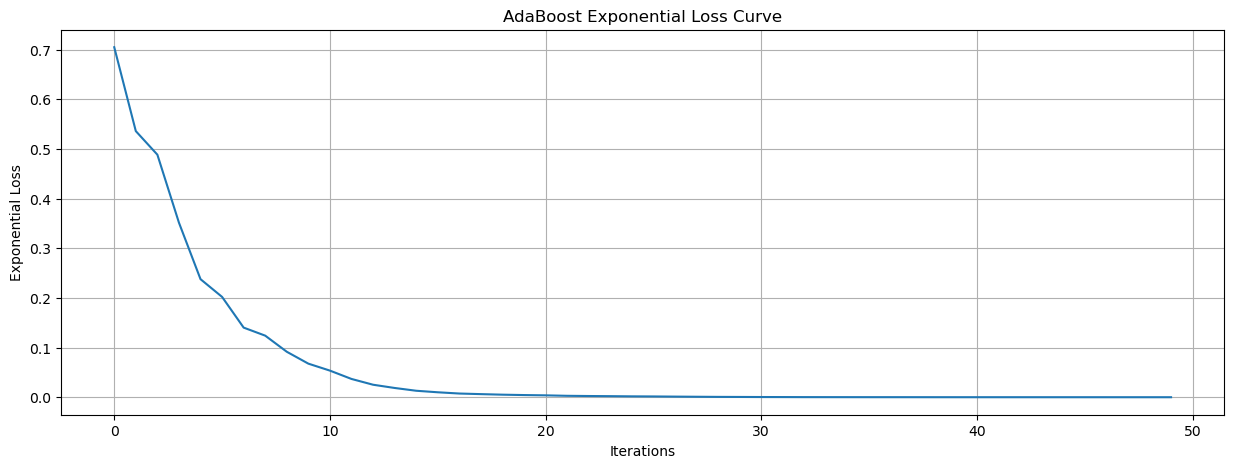

In [6]:
# Plot
plt.figure(figsize=(15,5))
plt.plot(train_loss, label="Train Loss")

plt.xlabel("Iterations")
plt.ylabel("Exponential Loss")
plt.title("AdaBoost Exponential Loss Curve")
plt.grid(True)
plt.show()


## 5. Interpretation

- AdaBoost focuses on misclassified samples  
- Hard samples receive increasing weight  
- Model becomes highly confident on training data  

---

## 6. Conclusion

This process shows AdaBoost reduces training loss aggressively  


---